In [5]:
import random
from math import sqrt
import numpy
rng = numpy.random.default_rng()




In [ ]:
#definizione di una funzione per una stima di pigreco "bruta" senza array, numpy o librerie particolari e utilizzabile da terminale

def pifun(N, K):
    """
    la funzione calcola una stima di pigreco e dell'incertezza sulla stima in K iterazioni da N punti, inserisci N e K
    """
    #input(N);
    #input(K);
    pi = [];
    for k in range(K):
        counter = 1;
        inside = 0;

        while counter <= N:

            x = random.uniform(-1,1);
            y = random.uniform(-1,1);

            if x**2 + y**2 <= 1:

                inside += 1;

            counter +=1;
        piest = 4*inside/counter;

        pi.append(piest);
        

    ave = sum(pi)/len(pi);

    if K == 1:

        return ave;

    else:
    

        varsq = []
        for i in range(len(pi)):
            varsq.append((pi[i] - ave)**2) 
        std = sqrt(sum(varsq)/len(pi));

        return ave, std
if __name__ == '__main__' :
    N = int(input('give me N = '))
    K = int(input('give me K = '))
    if K == 1:
        ave = pifun(N, K)
        print(ave)
    else:
        [ave,std] = pifun(N,K)
        print(ave, std)

In [6]:
#per la seconda parte dell'esercizio creo una funzione che sfrutti il broadcasting in modo da velocizzare il processo di stima
#e poterla inserire in un loop anche importante senza morire di vecchiaia

def pinpy(N, K):

    pi = [];
    for k in range(K):

        x = rng.uniform(low=-1, high=1, size=N)
        y = rng.uniform(low=-1, high=1, size=N)

        gianni = x*x + y*y;

        target = (gianni <=1);


        piest = 4*target.sum()/target.size;
        pi.append(piest);

    ave = sum(pi)/len(pi);

    varsq = [];
    for i in range(len(pi)):
        varsq.append((pi[i] - ave)**2); 
    std = sqrt(sum(varsq)/len(pi));

    return ave, std

In [13]:
#reiteriamo più volte la funzione di stima e vediamo come varia la deviazione standard 
#divertente vedere il guadagno temporale passando da pifun a pinpy


import matplotlib.pyplot as plt
import matplotlib.scale as mscale
import time
start = time.time()

pi = [];

errore = [];
punti = [];
verifica = [];
for i in range(1,100):
    points=i*2000;
    punti.append(points);
    [ave,std] = pinpy(points,50);
    pi.append(ave);
    errore.append(std);
    
    verifica.append(1/sqrt(points))

end = time.time()
print(end - start)



8.382277965545654


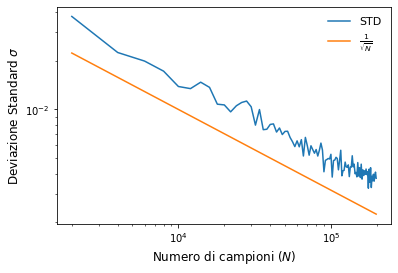

In [17]:
fig, ax = plt.subplots()
ax.plot(punti,errore, label= 'STD')
ax.plot(punti,verifica, label = r'$\frac{1}{\sqrt{N}}$')
ax.set_xscale('log')
ax.set_yscale('log')
plt.xlabel(r'Numero di campioni ($N$)', fontsize=12)
plt.ylabel(r'Deviazione Standard $\sigma$', fontsize=12)
plt.minorticks_on()
plt.legend(fontsize=11, frameon=False)